
# Spotify Data Analytics Capstone Project

## Objective
Analyze Spotify music data to uncover:
- Music trends over time
- Popular audio characteristics
- Artist and genre patterns
- Correlation between song features and popularity

---

## Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

---

## Dataset Files
- `data.csv`
- `data_by_year.csv`
- `data_by_artist.csv`
- `data_by_genres.csv`

This notebook is written in a project style suitable for academic submission and portfolio showcase.


In [1]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [3]:
import zipfile

# Load Dataset
zip_file_path = '/content/Cap 4 Spotify Data Analytics-20260516T130212Z-3-001.zip'
csv_file_name = 'Cap 4 Spotify Data Analytics/data.csv'

# Extract the specific CSV file from the ZIP archive
with zipfile.ZipFile(zip_file_path, 'r') as zf:
    with zf.open(csv_file_name) as f:
        df = pd.read_csv(f)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (170653, 19)


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665



# Dataset Overview

The dataset contains Spotify track-level information such as:
- Danceability
- Energy
- Popularity
- Loudness
- Tempo
- Acousticness
- Speechiness
- Explicit content
- Release year

The dataset contains more than 170,000 songs collected across multiple decades.


In [4]:

# Basic Information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [5]:

# Missing Values

missing_values = df.isnull().sum()

missing_values[missing_values > 0]


,0


In [6]:

# Statistical Summary

df.describe()


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.084575,0.167010,5.199844,0.205839,-11.467990,0.706902,31.431794,0.098393,116.861590
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.278249,0.313475,3.515094,0.174805,5.697943,0.455184,21.826615,0.162740,30.708533
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.000000,2.000000,0.098800,-14.615000,0.000000,11.000000,0.034900,93.421000
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000000,0.000216,5.000000,0.136000,-10.580000,1.000000,33.000000,0.045000,114.729000
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.000000,0.102000,8.000000,0.261000,-7.183000,1.000000,48.000000,0.075600,135.537000
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,11.000000,1.000000,3.855000,1.000000,100.000000,0.970000,243.507000



# Data Cleaning

We will:
- Remove duplicate records
- Check invalid values
- Convert duration from milliseconds to minutes


In [7]:

# Remove Duplicates

before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]

print("Removed Duplicates:", before - after)


Removed Duplicates: 0


In [8]:

# Convert Duration to Minutes

df['duration_min'] = df['duration_ms'] / 60000

df[['duration_ms', 'duration_min']].head()


,duration_ms,duration_min
0,831667,13.861117
1,180533,3.008883
2,500062,8.334367
3,210000,3.500000
4,166693,2.778217



# Exploratory Data Analysis (EDA)


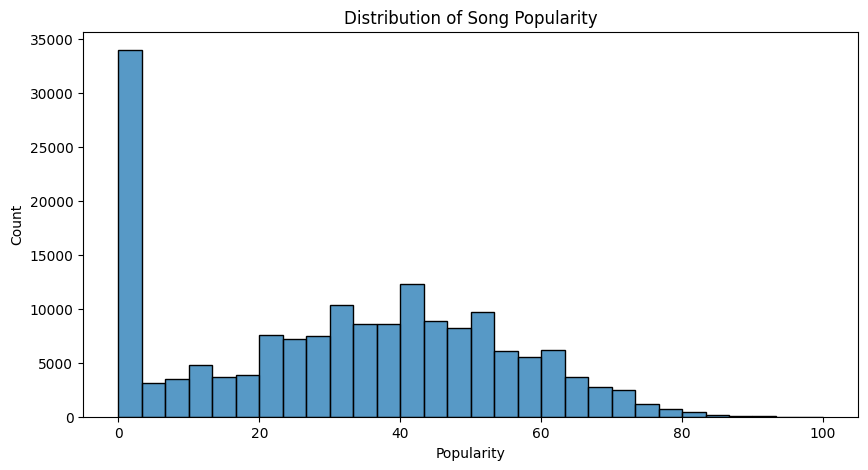

In [9]:

# Distribution of Popularity

plt.figure(figsize=(10,5))

sns.histplot(df['popularity'], bins=30)

plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity')
plt.ylabel('Count')

plt.show()



### Insight
Most songs in the dataset have low to medium popularity, while only a small number of tracks achieve very high popularity scores.


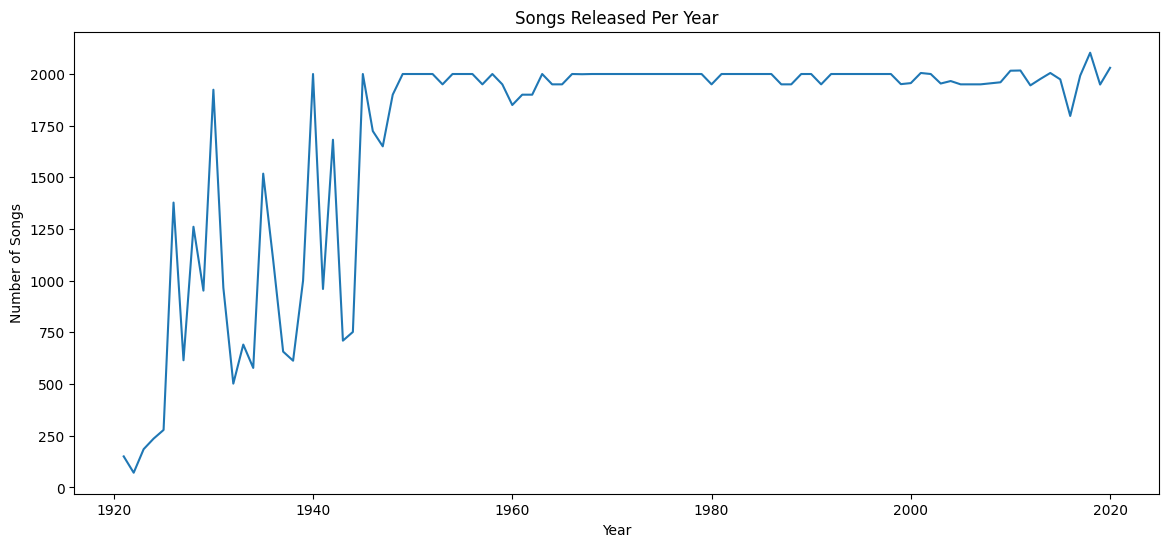

In [10]:

# Songs Released Per Year

songs_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(14,6))

songs_per_year.plot()

plt.title('Songs Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Songs')

plt.show()



### Insight
The number of songs increased rapidly after 2000, showing the expansion of digital music platforms and streaming services.


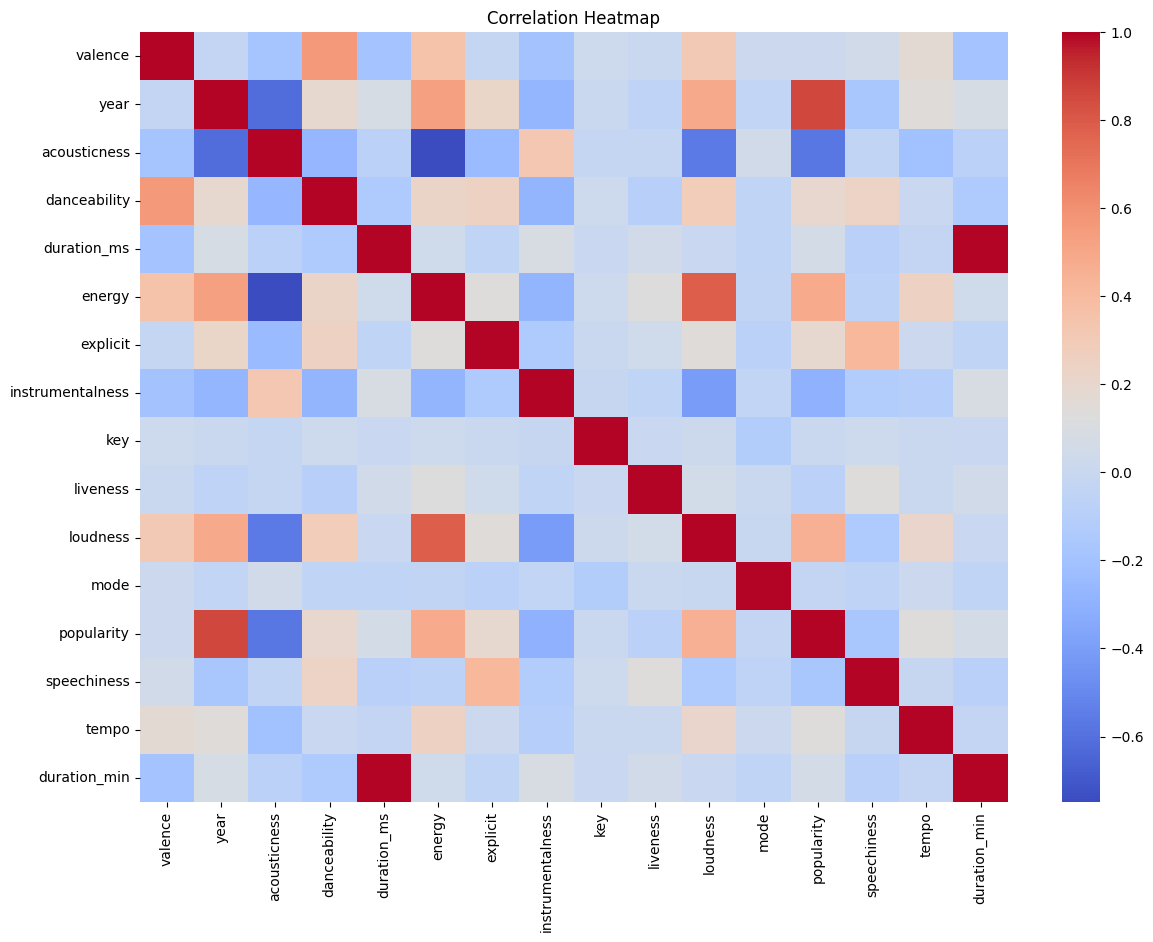

In [11]:

# Correlation Heatmap

numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(14,10))

sns.heatmap(corr, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()



### Insight
- Energy and loudness show strong positive correlation.
- Acousticness negatively correlates with energy.
- Danceability has moderate relation with popularity.


In [12]:

# Top 10 Most Popular Songs

top_tracks = df[['name', 'artists', 'popularity']].sort_values(
    by='popularity',
    ascending=False
).head(10)

top_tracks


,name,artists,popularity
19611,Dakiti,"['Bad Bunny', 'Jhay Cortez']",100
19606,Mood (feat. iann dior),"['24kGoldn', 'iann dior']",99
19618,Dynamite,['BTS'],97
19616,Blinding Lights,['The Weeknd'],96
19608,WAP (feat. Megan Thee Stallion),"['Cardi B', 'Megan Thee Stallion']",96
19610,positions,['Ariana Grande'],96
19612,What You Know Bout Love,['Pop Smoke'],96
19615,Holy (feat. Chance The Rapper),"['Justin Bieber', 'Chance the Rapper']",95
19607,For The Night (feat. Lil Baby & DaBaby),"['Pop Smoke', 'Lil Baby', 'DaBaby']",95
19623,you broke me first,['Tate McRae'],95


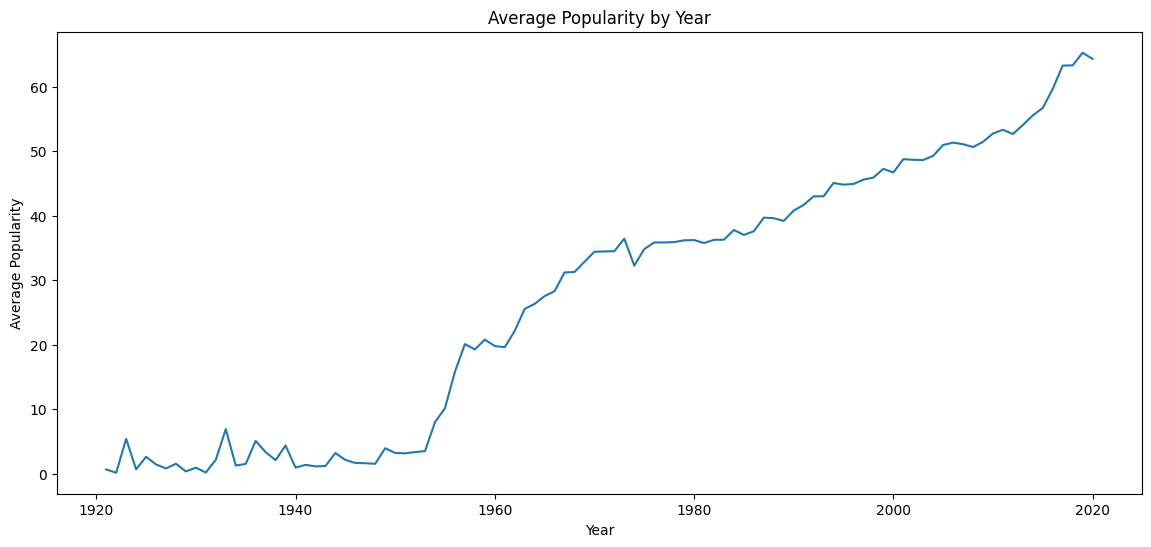

In [13]:

# Average Popularity by Year

yearly_popularity = df.groupby('year')['popularity'].mean()

plt.figure(figsize=(14,6))

yearly_popularity.plot()

plt.title('Average Popularity by Year')
plt.xlabel('Year')
plt.ylabel('Average Popularity')

plt.show()



### Insight
Average popularity has generally increased over time because newer tracks receive more streaming attention on Spotify.


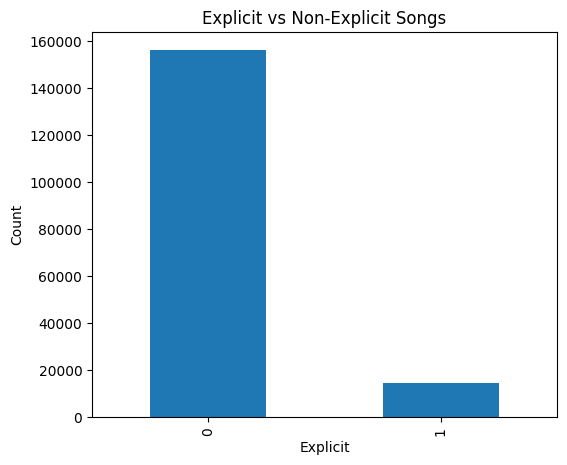

In [14]:

# Explicit vs Non-Explicit Songs

explicit_counts = df['explicit'].value_counts()

plt.figure(figsize=(6,5))

explicit_counts.plot(kind='bar')

plt.title('Explicit vs Non-Explicit Songs')
plt.xlabel('Explicit')
plt.ylabel('Count')

plt.show()



### Insight
Non-explicit songs dominate the dataset, but explicit tracks have become more common in modern music trends.


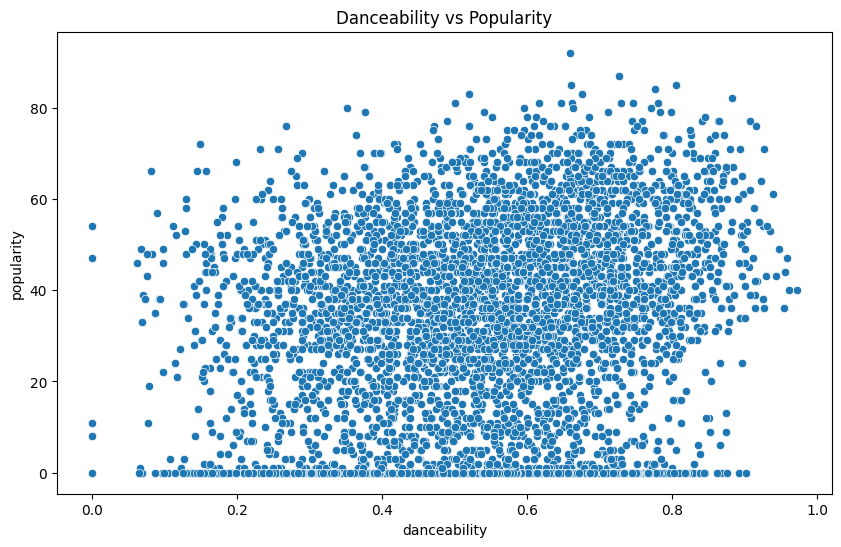

In [15]:

# Danceability vs Popularity

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='danceability',
    y='popularity',
    data=df.sample(5000, random_state=42)
)

plt.title('Danceability vs Popularity')

plt.show()



### Insight
Songs with moderate to high danceability tend to achieve better popularity scores on average.


In [ ]:

# Energy Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['energy'], bins=30)

plt.title('Energy Distribution')

plt.show()



### Insight
Most Spotify tracks have medium to high energy levels, indicating listener preference toward energetic music.


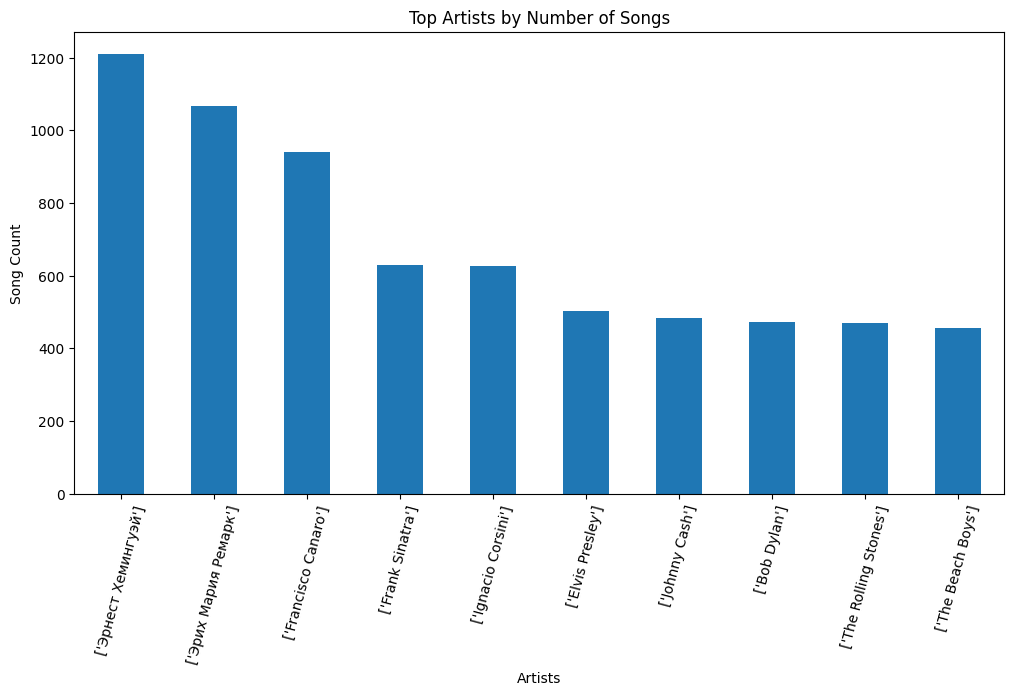

In [16]:

# Top Artists by Number of Songs

top_artists = df['artists'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_artists.plot(kind='bar')

plt.title('Top Artists by Number of Songs')
plt.xlabel('Artists')
plt.ylabel('Song Count')

plt.xticks(rotation=75)

plt.show()



### Final Conclusion

Key Findings:
- Spotify music production increased rapidly after 2000.
- Energy and loudness are strongly connected audio features.
- Danceable tracks generally perform better in popularity.
- Non-explicit songs still dominate the platform.
- Modern tracks receive higher streaming visibility and popularity.

This project demonstrates:
- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Business Insight Generation
- Trend Analysis
